<a href="https://colab.research.google.com/github/jfleon-dev/university-ai-labs/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bases de datos con alta varianza

In [ ]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_vino = pd.read_csv("wine.csv")
variedades = df_vino["class_name"]
muestras = df_vino.drop("class_name",axis = 1)

In [ ]:
modelo = KMeans(n_clusters=3)
etiquetas = modelo.fit_predict(muestras)
print(etiquetas)

[1 1 2 2 1 2 2 2 1 1 2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 1 2 2 1 1 2 2 1 2 1 1 1
 1 1 1 1 1 1 0 1 1 1 1 1 2 2 2 2 2 1 2 1 2 2 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1
 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 1 1 0]


In [ ]:
pd.crosstab(etiquetas,variedades)

class_name,Barbera,Barolo,Grignolino
row_0,,,
0,37,1,64
1,11,31,7
2,0,27,0


El modelo es muy malo porque tenemos alta varianza en los datos. Proline tiene mucha varianza

In [ ]:
muestras.var()

,0
class_label,0.600679
alcohol,0.659062
malic_acid,1.248015
ash,0.075265
alcalinity_of_ash,11.152686
magnesium,203.989335
total_phenols,0.391690
flavanoids,0.997719
nonflavanoid_phenols,0.015489
proanthocyanins,0.327595


Cuando la varianza es baja, los datos normales se ven como en la siguiente gráfica

(np.float64(0.10350000000000001),
 np.float64(1.4565000000000001),
 np.float64(0.4185),
 np.float64(1.7715))

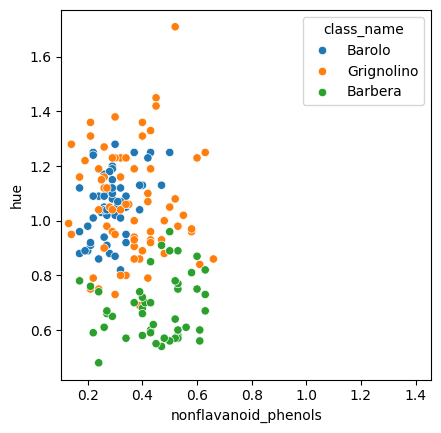

In [ ]:
sns.scatterplot(data=df_vino, x='nonflavanoid_phenols', y='hue', hue='class_name')
plt.axis('square')


Una gráfica anormal se ve como en la siguiente figura. Note la diferencia entre las escalas de ambos ejes

(-1000.0, 1000.0)

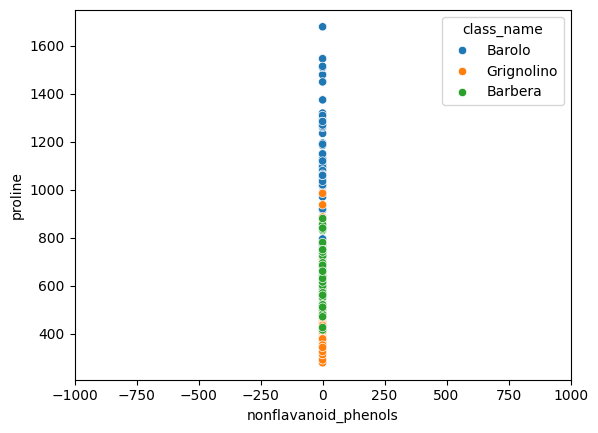

In [ ]:
sns.scatterplot(data=df_vino, x='nonflavanoid_phenols', y='proline', hue='class_name')
plt.xlim(-1000, 1000)

Solución: Normalizar los datos. Es decir, poner todo en escala similar

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(muestras)
StandardScaler(copy=True, with_mean=True, with_std=True)
muestras_scaled = scaler.transform(muestras)

Calculando nuevamente la varianza

In [ ]:
pd.DataFrame(muestras_scaled).var()

,0
0,1.00565
1,1.00565
2,1.00565
3,1.00565
4,1.00565
5,1.00565
6,1.00565
7,1.00565
8,1.00565
9,1.00565


In [ ]:
#Clustering como debe de ser
etiquetas_2= modelo.fit_predict(muestras_scaled)

pd.crosstab(etiquetas_2,variedades)

class_name,Barbera,Barolo,Grignolino
row_0,,,
0,0,59,3
1,48,0,1
2,0,0,67


## Ejercicio 1
Se le proporciona una base de datos de muestras con medidas de peces. Cada fila representa un pez individual. Las medidas, como el peso en gramos, la longitud en centímetros y la relación porcentual entre la altura y la longitud, tienen escalas muy diferentes. Para agrupar estos datos eficazmente, primero deberá estandarizar estas características.

- Importa la base de datos del archivo "fish.csv"
- Separa las clases de pescados presentes en la primer columna del resto de los datos.
- Crear una instancia de StandardScaler llamada scaler y normaliza los datos.
- Crear una instancia de KMeans y explora el número de clusters apropiado usando las técnicas que conoces.

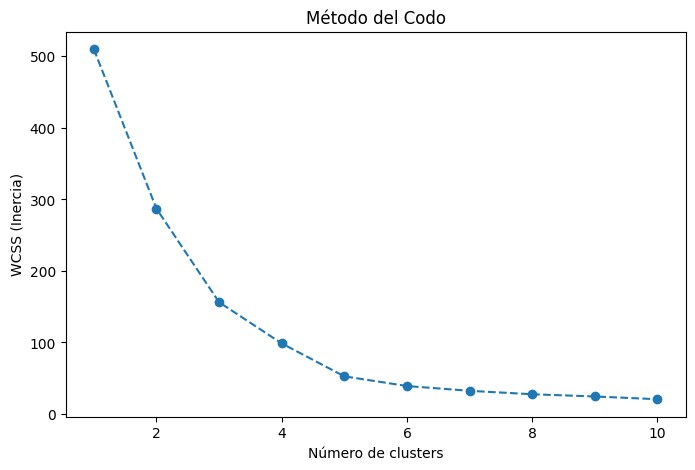

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df_fish = pd.read_csv("fish.csv", names=['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'])
fish_species = df_fish["Species"]
fish_features = df_fish.drop("Species", axis=1)


scaler = StandardScaler()
fish_scaled = scaler.fit_transform(fish_features)

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(fish_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS (Inercia)')
plt.show()

kmeans_final = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
etiquetas = kmeans_final.fit_predict(fish_scaled)

- Utilizando pd.DataFrame(), crear un DataFrame df con dos columnas llamadas "etiquetas" y "especie", utilizando etiquetas y especies, respectivamente, para los valores de las columnas.
- Utilizando pd.crosstab(), crear una tabulación cruzada ct de df['etiquetas'] y df['especie'].

In [ ]:
df = pd.DataFrame({'etiquetas': etiquetas, 'especie': fish_species})
ct = pd.crosstab(df['etiquetas'], df['especie'])
print(ct)

especie    Bream  Pike  Roach  Smelt
etiquetas                           
0              0     0      0     13
1              1     0     19      1
2             33     0      1      0
3              0    17      0      0
